In [103]:
resultsDir = "results_updated/sweep"
simListFile = f"{resultsDir}/simRuns.txt"

SHARE_DIR = "/imec/other/dtpatha/patel23/share/llmcompass"

batch_size = 8


In [97]:
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn scipy --user


The following have been reloaded with a version change:
  1) devel/ncurses/6.5 => devel/ncurses/6.2-GCCcore-11.2.0

Lmod has detected the following error:  Unable to load module
because of error when evaluating modulefile:
     /imec/other/pathfind/modules/pathfind/conda/current.lua: [string
"help("Load conda and mamba for the pathfind environment")..."]:8: attempt to
call a nil value (global 'source_sh')
     Please check the modulefile and especially if there is a the line number
specified in the above message 
While processing the following module(s):
    Module fullname         Module Filename
    ---------------         ---------------
    pathfind/conda/current  /imec/other/pathfind/modules/pathfind/conda/current.lua

     |████████████████████████████████| 38.6 MB 11.0 MB/s eta 0:00:01
     |████████████████████████████████| 19.5 MB 70.3 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [104]:
import matplotlib.pyplot as plt

import seaborn as sns
import csv
import pandas as pd
import scipy.io

import shutil

from Loader import Loader

In [105]:
# Loading lsit of simulations that were done
simRuns = []
with open(f"{simListFile}", "r") as file:
    simRuns = file.readlines()
          
# Post process for prefill and generation
initList = []
ar_list = []
cnt = 0
totalSims = len(simRuns)
# Iterate through all simulation results
for cSim in simRuns:
    cSim = cSim.replace("\n", "")
    cnt += 1
    '''
    loader = Loader(
                f"[{cnt}]/[{totalSims}] Running sims ...",
                "[Done!]",
                0.05,
            ).start()
    '''
    _tmpSplitStr = cSim.split("_")
    results_init = pd.read_csv(
        f"{resultsDir}/{cSim}_init.csv",
        header=None,
        names=col_names,
        index_col=0,
    )
    results_init.index.astype(float)
    results_ar = pd.read_csv(
        f"{resultsDir}/{cSim}_ar.csv",
        header=None,
        names=col_names,
        index_col=0,
    )
    results_ar.index.astype(float)
    
    x = 0
    x_labels = results_init.index.tolist()
    # for row_index in x_labels:
    for i in range(0, len(results_init)):
        x = x + 1
        values = results_init.iloc[x - 1].tolist()

        bottom = 0
        cData = {
            "Sim": cSim,
            "Bug": str(x),
            "Memory": _tmpSplitStr[1],
            "Mem per chiplet": _tmpSplitStr[2],
            "Mem BW": results_init.iloc[x - 1, 0],
            "Interconnect": _tmpSplitStr[4],
        }
        _total_time = 0
        for _key, _value in zip(categories, values[2:]):
            cData[_key] = _value
            _total_time += _value
            
        cData["Total Time"] = _total_time

        initList.append(cData)

    x = 0
    x_labels = results_ar.index.tolist()
    for row_index in x_labels:
        x = x + 1
        try:
            values = results_ar.loc[row_index].tolist()
            # print(results_init.loc[row_index])
        except:
            values = results_ar.iloc[x - 1].tolist()
            # print(results_init.iloc[x - 1])
        # values = results_ar.loc[row_index].tolist()
        bottom = 0
        cData = {
            "Sim": cSim,
            "Bug": str(x),
            "Memory": _tmpSplitStr[1],
            "Mem per chiplet": _tmpSplitStr[2],
            "Mem BW": row_index,
            "Interconnect": _tmpSplitStr[4],
        }
        _total_time = 0
        for _key, _value in zip(categories, values[2:]):
            cData[_key] = _value
            _total_time += _value
            
        cData["Total Time"] = _total_time

        ar_list.append(cData)
    
    # loader.stop()
pd_prefill = pd.DataFrame(initList)
pd_generation = pd.DataFrame(ar_list)

In [106]:
# Plotting snippets
# By now, we have initList and ar_list with all the data in dict
# Some globlas related to LLM compass, the way csv was logged, check in ae/simRuns/
categories = [
    "Q_K_V",
    "Q_mul_K",
    "A_mul_V",
    "Wo_proj",
    "W1_proj",
    "W2_proj",
    "Softmax",
    "LayerNorm_MHA",
    "LayerNorm_FFN",
    "GeLU",
    "AllReduce_MHA",
    "AllReduce_FFN",
]
col_names = ["area", "latency"] + categories

colors_matmul = sns.color_palette("flare_r", 6)
colors_normalization = sns.color_palette("summer", 3)
colors_gelu = sns.color_palette("pink", 1)
colors_allreduce = sns.color_palette("Blues_r", 2)
colors = colors_matmul + colors_normalization + colors_gelu + colors_allreduce

<Figure size 432x288 with 0 Axes>

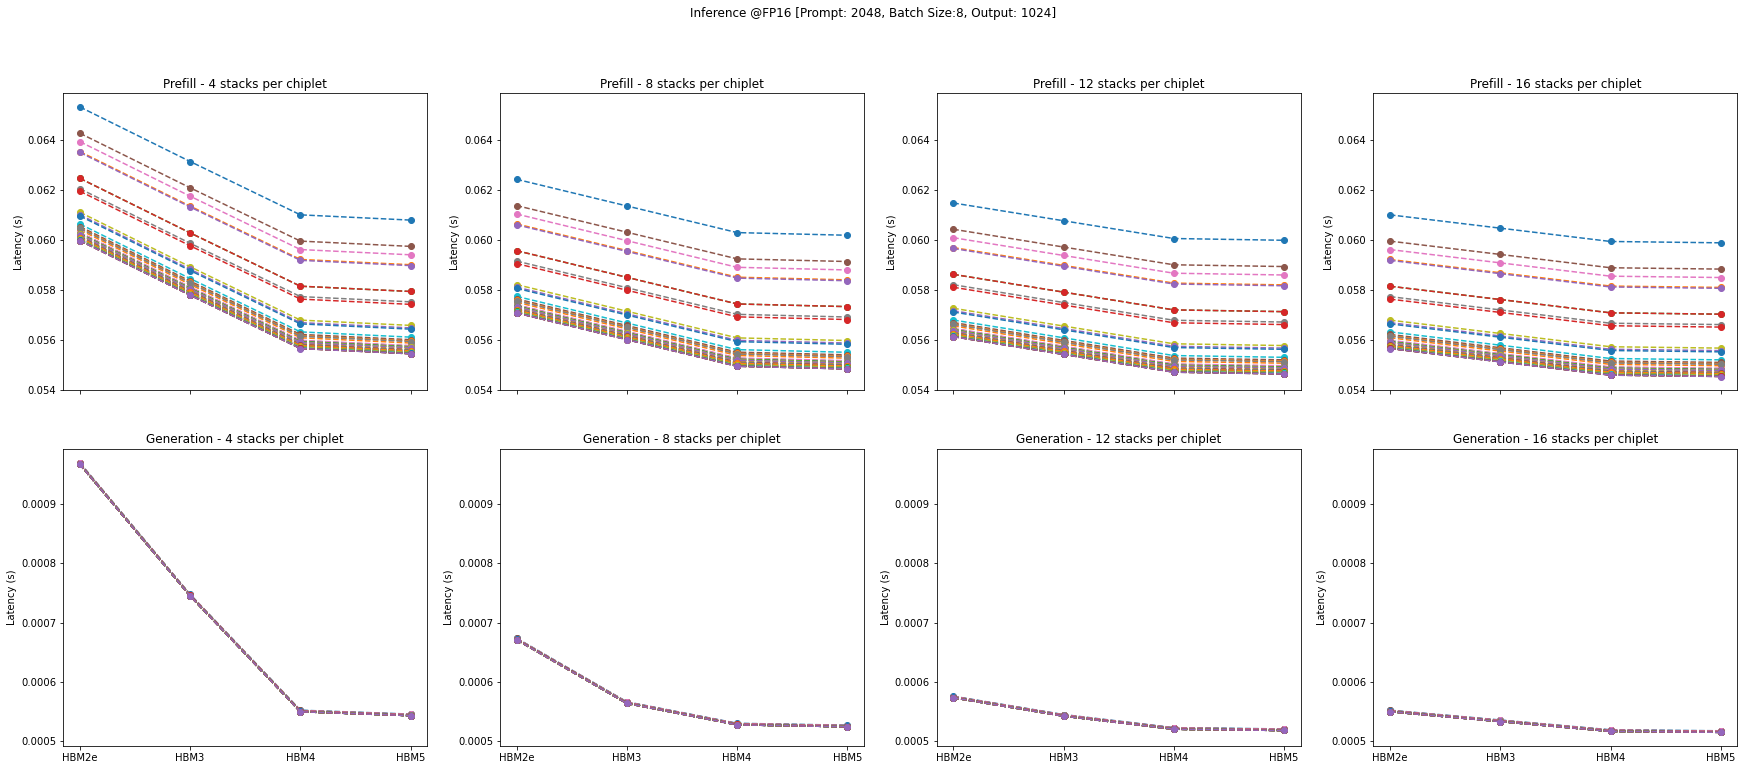

In [107]:
#  HBM scaling with different interconnects

_stacks = {}
x = 0
#plt.figure(figsize=(160, 20))
plt.figure()
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(30, 12), sharey='row', sharex='col')#,sharex=True)

for _cStack in ["4", "8", "12", "16"]:

    _stacks[_cStack] = {}
    _stacks[_cStack]["Prefill"] = pd_prefill[pd_prefill['Mem per chiplet'] == _cStack]
    _stacks[_cStack]["Generation"] = pd_generation[pd_generation['Mem per chiplet'] == _cStack]
    #display(_stacks[_cStack]["Prefill"].sort_values(by=["Interconnect", "Memory"]))
    r = 0
    for sim in ["Prefill", "Generation"]:
        _plt = ax[r, x]
        _interconnts = _stacks[_cStack][sim]["Interconnect"].unique()
        for cInterconnect in _stacks[_cStack][sim]["Interconnect"].unique():
            _stacks[_cStack][f"{cInterconnect}"] = _stacks[_cStack][sim][_stacks[_cStack][sim]["Interconnect"] == cInterconnect]
            #display(_stacks[_cStack][f"{cInterconnect}"])
            _plt.plot(_stacks[_cStack][f"{cInterconnect}"]["Memory"], _stacks[_cStack][f"{cInterconnect}"]["Total Time"], 'o--',label = cInterconnect)

        #handles, labels = plt.gca().get_legend_handles_labels()
        #plt.legend(_interconnts, loc="upper right")#, bbox_to_anchor=(1, 1.05))
        _plt.set_title(f"{sim} - {_cStack} stacks per chiplet")
        _plt.set_ylabel("Latency (s)")
        _plt.yaxis.set_tick_params(labelleft=True)
        #if r == 0:
        #    _plt.set_ylim([0.052, 0.068])
        #else:
        #    _plt.set_ylim()
        #plt.tight_layout()    
        r += 1
    x += 1

fig.suptitle(f"Inference @FP16 [Prompt: 2048, Batch Size:8, Output: 1024]")        
plt.show()


In [99]:
scipy.io.savemat(f'{resultsDir}/Inference.mat', {'Prefill':pd_prefill.to_dict("list"), "Generation": pd_generation.to_dict("list")})

with open(f"{resultsDir}/prefill.csv", "w", newline="") as csvfile:
    fieldnames = initList[0].keys()
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(initList)
    
with open(f"{resultsDir}/generation.csv", "w", newline="") as csvfile:
    fieldnames = ar_list[0].keys()
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(ar_list)

In [100]:
# Optional for sharing of csvs
shutil.copy(f'{resultsDir}/Inference.mat', f'{SHARE_DIR}/Inference.mat')

destFile = f"{SHARE_DIR}/prefill.csv"
shutil.copy(f"{resultsDir}/prefill.csv", destFile)

destFile = f"{SHARE_DIR}/generation.csv"
shutil.copy(f"{resultsDir}/generation.csv", destFile)

'/imec/other/dtpatha/patel23/share/llmcompass/generation.csv'